In [1]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

In [2]:
# Load events dataset
events = pd.read_csv("../data/01-raw/events.csv")

In [3]:
# Preview events dataset
print(events.shape)
events.head()

(30000, 18)


,event_id,user_id,session_id,listing_id,event_time,device_type,traffic_source,room_type,city,price,price_log,demand_score,availability_ratio,impression,click,detail_view,save,contact
0,1,35015,587281,12775106,2025-03-10 01:50:00,mobile,email,Entire home/apt,Queens,120,4.795791,0.03,0.000000,1,1,0,0,0
1,2,89720,182859,304799,2025-02-23 07:15:00,mobile,organic,Entire home/apt,Manhattan,150,5.017280,1.43,0.005479,1,1,1,1,1
2,3,76186,894861,30120067,2025-03-26 04:40:00,tablet,organic,Shared room,Bronx,50,3.931826,10.08,0.660274,1,1,1,0,1
3,4,74430,354595,34387952,2025-03-08 03:28:00,desktop,organic,Entire home/apt,Manhattan,250,5.525453,0.88,0.167123,1,1,1,1,1
4,5,59185,360425,8754339,2025-02-27 08:03:00,mobile,email,Shared room,Manhattan,60,4.110874,0.00,0.000000,1,0,0,0,0


In [4]:
# Inspect dataset structure
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   event_id            30000 non-null  int64  
 1   user_id             30000 non-null  int64  
 2   session_id          30000 non-null  int64  
 3   listing_id          30000 non-null  int64  
 4   event_time          30000 non-null  object 
 5   device_type         30000 non-null  object 
 6   traffic_source      30000 non-null  object 
 7   room_type           30000 non-null  object 
 8   city                30000 non-null  object 
 9   price               30000 non-null  int64  
 10  price_log           30000 non-null  float64
 11  demand_score        30000 non-null  float64
 12  availability_ratio  30000 non-null  float64
 13  impression          30000 non-null  int64  
 14  click               30000 non-null  int64  
 15  detail_view         30000 non-null  int64  
 16  save

In [5]:
# Check missing values
events.isnull().sum()

event_id              0
user_id               0
session_id            0
listing_id            0
event_time            0
device_type           0
traffic_source        0
room_type             0
city                  0
price                 0
price_log             0
demand_score          0
availability_ratio    0
impression            0
click                 0
detail_view           0
save                  0
contact               0
dtype: int64

In [6]:
# Compute overall funnel rates
funnel_summary = pd.DataFrame({
    "stage": ["impression", "click", "detail_view", "save", "contact"],
    "rate": [
        events["impression"].mean(),
        events["click"].mean(),
        events["detail_view"].mean(),
        events["save"].mean(),
        events["contact"].mean()
    ]
})

In [7]:
funnel_summary

,stage,rate
0,impression,1.000000
1,click,0.626433
2,detail_view,0.468367
3,save,0.307967
4,contact,0.293333


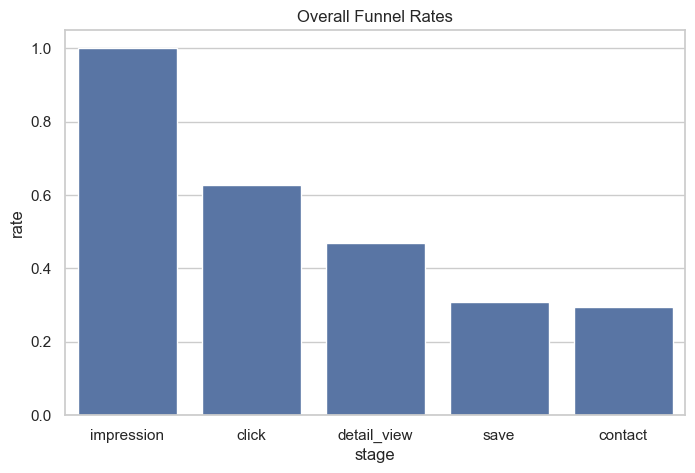

In [8]:
# Plot funnel rates
plt.figure(figsize=(8, 5))
sns.barplot(data=funnel_summary, x="stage", y="rate")
plt.title("Overall Funnel Rates")
plt.show()

In [10]:
# Compute click rate by device type
device_click = events.groupby("device_type")["click"].mean().reset_index()
device_click

,device_type,click
0,desktop,0.627173
1,mobile,0.626421
2,tablet,0.624240


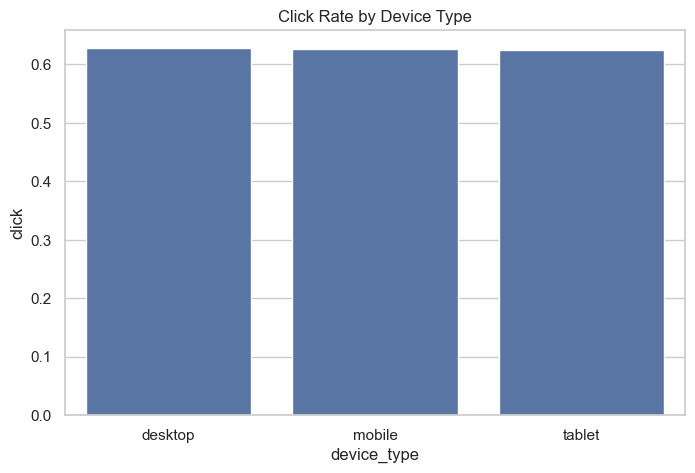

In [11]:
# Plot click rate by device type
plt.figure(figsize=(8, 5))
sns.barplot(data=device_click, x="device_type", y="click")
plt.title("Click Rate by Device Type")
plt.show()

In [12]:
# Compute contact rate by traffic source
traffic_contact = events.groupby("traffic_source")["contact"].mean().reset_index()
traffic_contact

,traffic_source,contact
0,direct,0.301092
1,email,0.300135
2,organic,0.290641
3,paid,0.289044


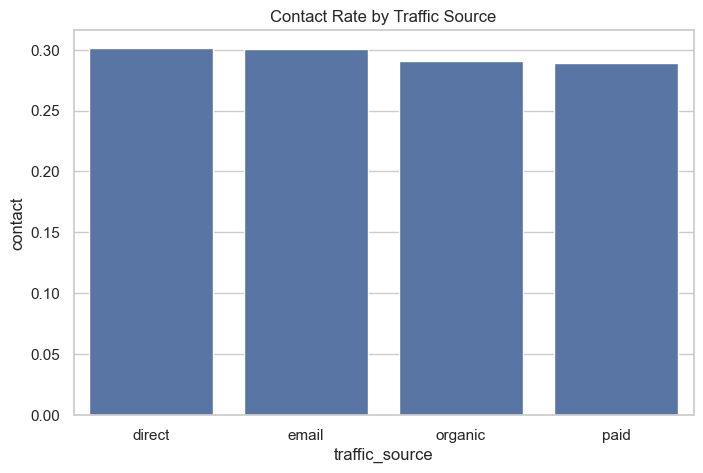

In [13]:
# Plot contact rate by traffic source
plt.figure(figsize=(8, 5))
sns.barplot(data=traffic_contact, x="traffic_source", y="contact")
plt.title("Contact Rate by Traffic Source")
plt.show()

In [14]:
# Compute click rate by room type
room_click = events.groupby("room_type")["click"].mean().reset_index()
room_click

,room_type,click
0,Entire home/apt,0.680828
1,Private room,0.567271
2,Shared room,0.585235


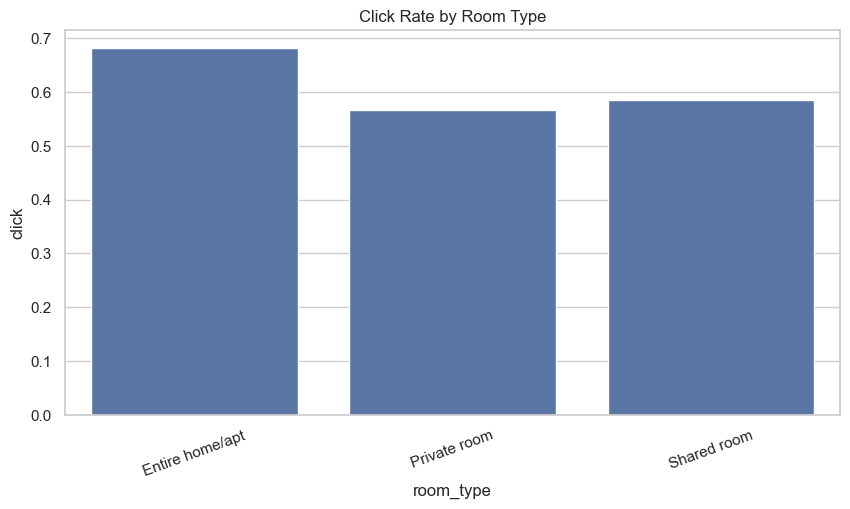

In [15]:
# Plot click rate by room type
plt.figure(figsize=(10, 5))
sns.barplot(data=room_click, x="room_type", y="click")
plt.title("Click Rate by Room Type")
plt.xticks(rotation=20)
plt.show()

In [16]:
# Compute contact rate by city
city_contact = events.groupby("city")["contact"].mean().reset_index().sort_values("contact", ascending=False)
city_contact

,city,contact
4,Staten Island,0.325000
0,Bronx,0.312399
2,Manhattan,0.308153
3,Queens,0.302504
1,Brooklyn,0.272950


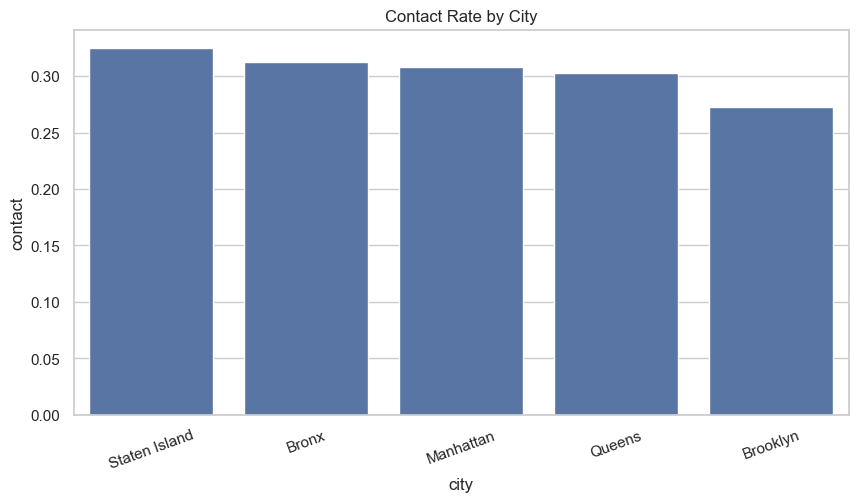

In [17]:
# Plot contact rate by city
plt.figure(figsize=(10, 5))
sns.barplot(data=city_contact, x="city", y="contact")
plt.title("Contact Rate by City")
plt.xticks(rotation=20)
plt.show()

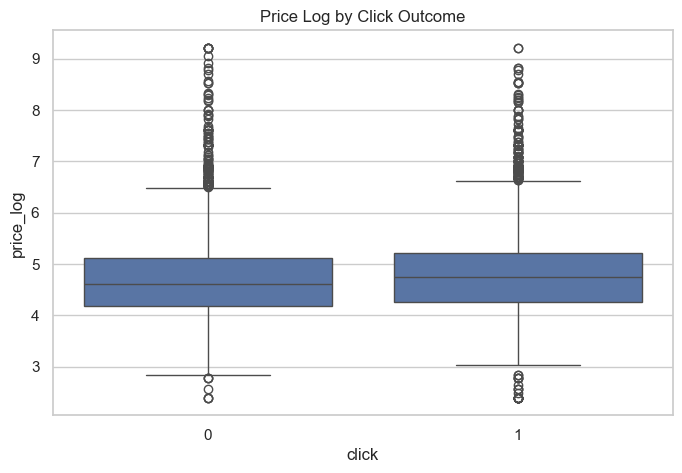

In [18]:
# Plot price log by click outcome
plt.figure(figsize=(8, 5))
sns.boxplot(data=events, x="click", y="price_log")
plt.title("Price Log by Click Outcome")
plt.show()

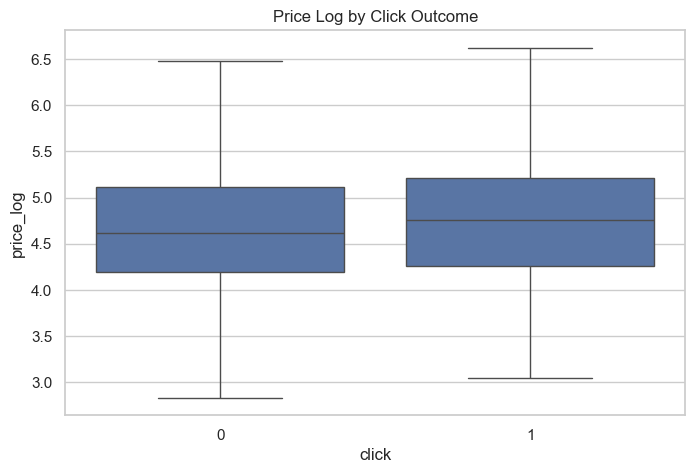

In [19]:
# Plot price log by click outcome
plt.figure(figsize=(8, 5))
sns.boxplot(data=events, x="click", y="price_log", showfliers=False)
plt.title("Price Log by Click Outcome")
plt.show()

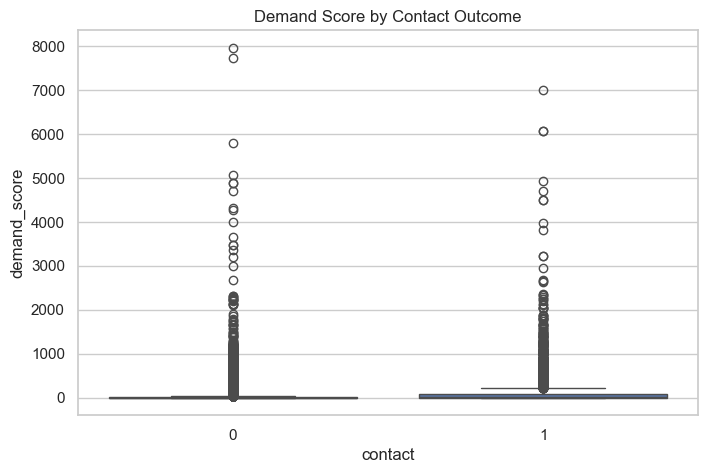

In [20]:
# Plot demand score by contact outcome
plt.figure(figsize=(8, 5))
sns.boxplot(data=events, x="contact", y="demand_score")
plt.title("Demand Score by Contact Outcome")
plt.show()

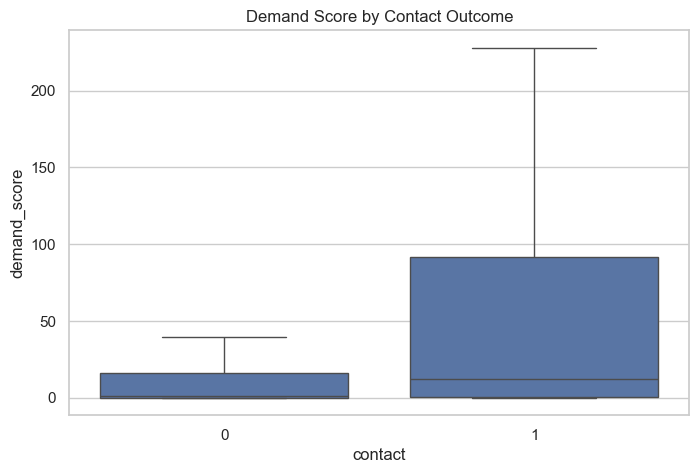

In [22]:
# Plot demand score by contact outcome
plt.figure(figsize=(8, 5))
sns.boxplot(data=events, x="contact", y="demand_score", showfliers=False)
plt.title("Demand Score by Contact Outcome")
plt.show()

In [23]:
# Compute correlation matrix
corr = events[[
    "price",
    "price_log",
    "demand_score",
    "availability_ratio",
    "click",
    "detail_view",
    "save",
    "contact"
]].corr()

corr

,price,price_log,demand_score,availability_ratio,click,detail_view,save,contact
price,1.000000,0.603265,-0.036743,0.066970,0.005021,0.001854,-0.017563,-0.018718
price_log,0.603265,1.000000,-0.052807,0.097231,0.059663,0.041109,0.021740,0.001248
demand_score,-0.036743,-0.052807,1.000000,0.107188,0.142249,0.104219,0.153763,0.119310
availability_ratio,0.066970,0.097231,0.107188,1.000000,0.171416,0.128154,0.117111,0.113604
click,0.005021,0.059663,0.142249,0.171416,1.000000,0.724826,0.515152,0.497531
detail_view,0.001854,0.041109,0.104219,0.128154,0.724826,1.000000,0.710725,0.686415
save,-0.017563,0.021740,0.153763,0.117111,0.515152,0.710725,1.000000,0.586290
contact,-0.018718,0.001248,0.119310,0.113604,0.497531,0.686415,0.586290,1.000000


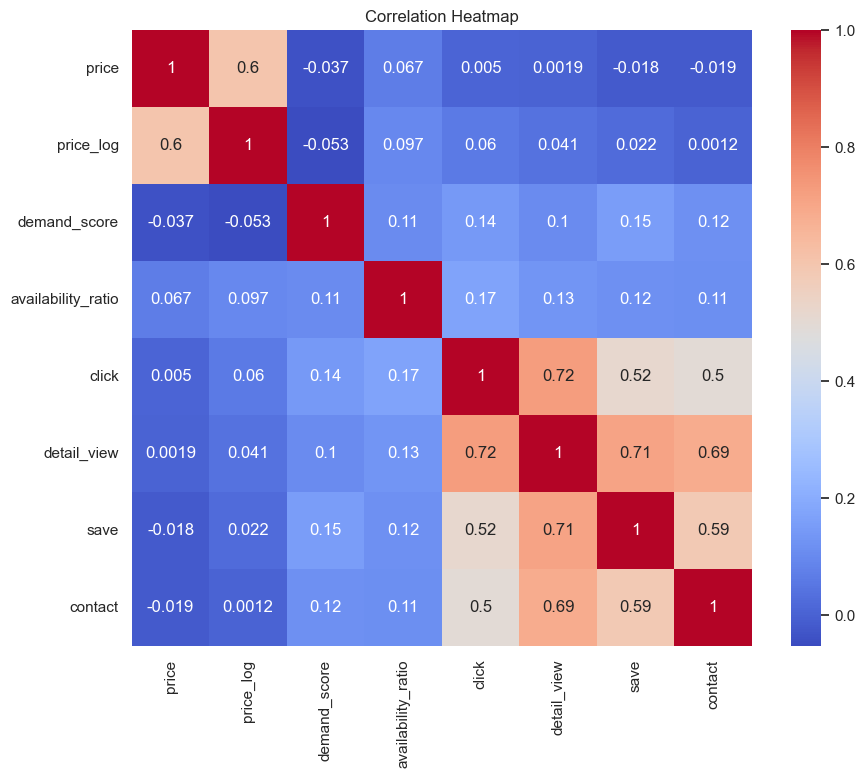

In [24]:
# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [25]:
# Check contact distribution
events["contact"].value_counts(normalize=True)

contact
0    0.706667
1    0.293333
Name: proportion, dtype: float64

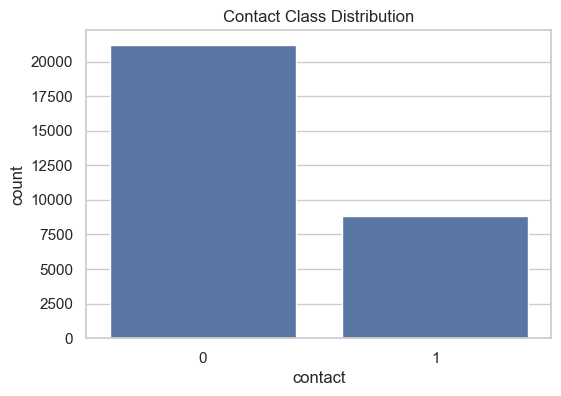

In [26]:
# Plot contact class balance
plt.figure(figsize=(6, 4))
sns.countplot(data=events, x="contact")
plt.title("Contact Class Distribution")
plt.show()

In [28]:
# Save funnel summary
funnel_summary.to_csv("../data/04-predictions/funnel_summary.csv", index=False)